# Media Pre-Processing Pipeline with Chunking & Noise Analysis

This notebook processes MP4 files by:
1. Separating audio and video streams
2. **Chunking into configurable time segments (default: 10 seconds)**
3. **Calculating A-weighted noise levels for each audio chunk**
4. Storing everything with temporal alignment metadata

## Requirements
- ffmpeg installed and in PATH
- Python 3.7+
- numpy (for audio analysis)

## 1. Import Required Libraries

In [12]:
import os
import sys
from pathlib import Path
import json
import numpy as np

# Import custom modules
from integrated_processor import IntegratedMediaProcessor
from media_utils import (
    check_dependencies, 
    print_dependency_status,
    format_duration,
    get_file_list
)

## 2. Check Dependencies

Verify that ffmpeg and ffprobe are installed and accessible.

In [13]:
dependencies = check_dependencies()
print_dependency_status(dependencies)

if not all(dependencies.values()):
    print("\n⚠️  WARNING: Some dependencies are missing!")
    print("Please install ffmpeg: https://ffmpeg.org/download.html")
else:
    print("\n✓ All dependencies are installed!")

Dependency Check:
------------------------------
ffmpeg          ✓ Installed
ffprobe         ✓ Installed
------------------------------

✓ All dependencies are installed!


## 3. Configure Directories and Chunk Duration

Set up input/output directories and chunking parameters.

In [14]:
# Define directories
INPUT_DIR = Path('./input_data_buffer')
OUTPUT_DIR = Path('./processed_media')

# Chunk duration in seconds (customize as needed)
CHUNK_DURATION = 10.0  # 10 seconds per chunk

# Create input directory if it doesn't exist
INPUT_DIR.mkdir(exist_ok=True)

print(f"Input Directory: {INPUT_DIR.absolute()}")
print(f"Output Directory: {OUTPUT_DIR.absolute()}")
print(f"Chunk Duration: {CHUNK_DURATION} seconds")

# Check if there are any MP4 files
mp4_files = get_file_list(INPUT_DIR, '*.mp4')
print(f"\nFound {len(mp4_files)} MP4 file(s) in input directory:")
for i, file in enumerate(mp4_files, 1):
    print(f"  {i}. {file.name}")

Input Directory: d:\Projects\UrbanNoiseClassifier\project\pre_inference\input_data_buffer
Output Directory: d:\Projects\UrbanNoiseClassifier\project\pre_inference\processed_media
Chunk Duration: 10.0 seconds

Found 1 MP4 file(s) in input directory:
  1. test_traffic_vid_1.mp4


## 4. Initialize Integrated Media Processor

Create an instance of the IntegratedMediaProcessor with chunking enabled.

In [15]:
processor = IntegratedMediaProcessor(
    input_dir=str(INPUT_DIR),
    output_base_dir=str(OUTPUT_DIR),
    chunk_duration=CHUNK_DURATION
)

print("IntegratedMediaProcessor initialized!")
print(f"  Full audio files: {processor.media_processor.audio_dir}")
print(f"  Full video files: {processor.media_processor.video_dir}")
print(f"  Audio chunks: {processor.audio_chunks_dir}")
print(f"  Video chunks: {processor.video_chunks_dir}")
print(f"  Chunk metadata: {processor.chunk_metadata_dir}")
print(f"  Noise analysis: {processor.noise_analysis_dir}")

IntegratedMediaProcessor initialized!
  Full audio files: processed_media\audio
  Full video files: processed_media\video
  Audio chunks: processed_media\audio_chunks
  Video chunks: processed_media\video_chunks
  Chunk metadata: processed_media\chunk_metadata
  Noise analysis: processed_media\noise_analysis


## 5. Process All MP4 Files

Complete processing pipeline:
1. Separate audio/video
2. Chunk into 10s segments (configurable)
3. Calculate A-weighted noise levels for each audio chunk
4. Generate comprehensive metadata

In [16]:
# Process all MP4 files with chunking and noise analysis
results = processor.process_all(audio_format='wav')

print(f"\nProcessed {len(results)} file(s) successfully")


INTEGRATED MEDIA PROCESSING PIPELINE
Files to process: 1
Chunk duration: 10.0s
Audio format: wav

Processing: test_traffic_vid_1.mp4

[1/4] Separating audio and video...
Extracting audio from test_traffic_vid_1.mp4...
Extracting video from test_traffic_vid_1.mp4...
Extracting video from test_traffic_vid_1.mp4...
✓ Successfully processed test_traffic_vid_1.mp4

[2/4] Chunking into 10.0s segments...
Chunking test_traffic_vid_1...
✓ Successfully processed test_traffic_vid_1.mp4

[2/4] Chunking into 10.0s segments...
Chunking test_traffic_vid_1...
  Created 60 audio chunks and 60 video chunks

[3/4] Analyzing audio chunks (A-weighted noise levels)...
  Created 60 audio chunks and 60 video chunks

[3/4] Analyzing audio chunks (A-weighted noise levels)...

[4/4] Creating metadata...

✓ Successfully processed test_traffic_vid_1.mp4
  - Created 60 audio chunks
  - Created 60 video chunks
  - Analyzed 60 audio segments

PROCESSING COMPLETE
Successful: 1
Failed: 0
Master index: processed_media\

## 6. View Noise Analysis Summary

Display A-weighted noise levels and statistics for processed files.

In [17]:
if results:
    for filename in results.keys():
        print(f"\n{'='*70}")
        noise_summary = processor.get_noise_summary(filename)
        
        if 'error' not in noise_summary:
            print(f"File: {filename}")
            print(f"Total chunks: {noise_summary.get('total_chunks', 0)}")
            print(f"Chunk duration: {noise_summary.get('chunk_duration', 0)}s")
            
            stats = noise_summary.get('statistics', {})
            if 'error' not in stats:
                spl_stats = stats.get('a_weighted_spl', {})
                leq_stats = stats.get('leq_a', {})
                
                print(f"\nA-Weighted SPL Statistics (dB(A)):")
                print(f"  Mean:   {spl_stats.get('mean', 0):.2f}")
                print(f"  Median: {spl_stats.get('median', 0):.2f}")
                print(f"  Min:    {spl_stats.get('min', 0):.2f}")
                print(f"  Max:    {spl_stats.get('max', 0):.2f}")
                print(f"  Std:    {spl_stats.get('std', 0):.2f}")
                
                print(f"\nLeq (Equivalent Continuous Level) - dB(A):")
                print(f"  Mean:   {leq_stats.get('mean', 0):.2f}")
                print(f"  Median: {leq_stats.get('median', 0):.2f}")
                print(f"  Min:    {leq_stats.get('min', 0):.2f}")
                print(f"  Max:    {leq_stats.get('max', 0):.2f}")
        else:
            print(f"Error loading noise summary for {filename}")
    
    print(f"\n{'='*70}")
else:
    print("No files have been processed yet.")


File: test_traffic_vid_1.mp4
Total chunks: 60
Chunk duration: 10.0s

A-Weighted SPL Statistics (dB(A)):
  Mean:   59.98
  Median: 59.07
  Min:    53.53
  Max:    83.80
  Std:    4.88

Leq (Equivalent Continuous Level) - dB(A):
  Mean:   59.98
  Median: 59.07
  Min:    53.53
  Max:    83.80



## 7. Inspect Individual Chunks

View detailed information for specific chunks including noise levels.

In [18]:
if results:
    # Get the first processed file
    sample_filename = list(results.keys())[0]
    
    print(f"File: {sample_filename}")
    print(f"\nChunk Details:")
    print("="*70)
    
    # Show first 5 chunks
    for chunk_idx in range(min(5, results[sample_filename].get('total_chunks', 0))):
        chunk_info = processor.get_chunk_info(sample_filename, chunk_idx)
        
        if 'error' not in chunk_info:
            noise_data = chunk_info.get('noise_analysis', {})
            
            print(f"\nChunk {chunk_idx}:")
            print(f"  Time: {chunk_info['start_time']:.1f}s - {chunk_info['end_time']:.1f}s")
            print(f"  Audio: {chunk_info['audio_chunk']}")
            print(f"  Video: {chunk_info['video_chunk']}")
            
            if 'error' not in noise_data:
                print(f"  A-weighted SPL: {noise_data.get('a_weighted_spl', 0):.2f} dB(A)")
                print(f"  Leq: {noise_data.get('leq_a', 0):.2f} dB(A)")
                print(f"  RMS: {noise_data.get('rms', 0):.6f}")
                print(f"  Peak: {noise_data.get('peak_db', 0):.2f} dB")
    
    print("\n" + "="*70)
else:
    print("No files have been processed yet.")

File: test_traffic_vid_1.mp4

Chunk Details:

Chunk 0:
  Time: 0.0s - 10.0s
  Audio: test_traffic_vid_1_chunk_0000.wav
  Video: test_traffic_vid_1_chunk_0000.mp4
  A-weighted SPL: 54.72 dB(A)
  Leq: 54.72 dB(A)
  RMS: 0.021366
  Peak: -17.01 dB

Chunk 1:
  Time: 10.0s - 20.0s
  Audio: test_traffic_vid_1_chunk_0001.wav
  Video: test_traffic_vid_1_chunk_0001.mp4
  A-weighted SPL: 58.86 dB(A)
  Leq: 58.86 dB(A)
  RMS: 0.033331
  Peak: -13.80 dB

Chunk 2:
  Time: 20.0s - 30.0s
  Audio: test_traffic_vid_1_chunk_0002.wav
  Video: test_traffic_vid_1_chunk_0002.mp4
  A-weighted SPL: 59.96 dB(A)
  Leq: 59.96 dB(A)
  RMS: 0.032589
  Peak: -12.96 dB

Chunk 3:
  Time: 30.0s - 40.0s
  Audio: test_traffic_vid_1_chunk_0003.wav
  Video: test_traffic_vid_1_chunk_0003.mp4
  A-weighted SPL: 61.35 dB(A)
  Leq: 61.35 dB(A)
  RMS: 0.039809
  Peak: -12.80 dB

Chunk 4:
  Time: 40.0s - 50.0s
  Audio: test_traffic_vid_1_chunk_0004.wav
  Video: test_traffic_vid_1_chunk_0004.mp4
  A-weighted SPL: 64.95 dB(A)
  Le

## 8. Visualize Noise Levels Over Time

Plot A-weighted noise levels for each chunk to see temporal patterns.

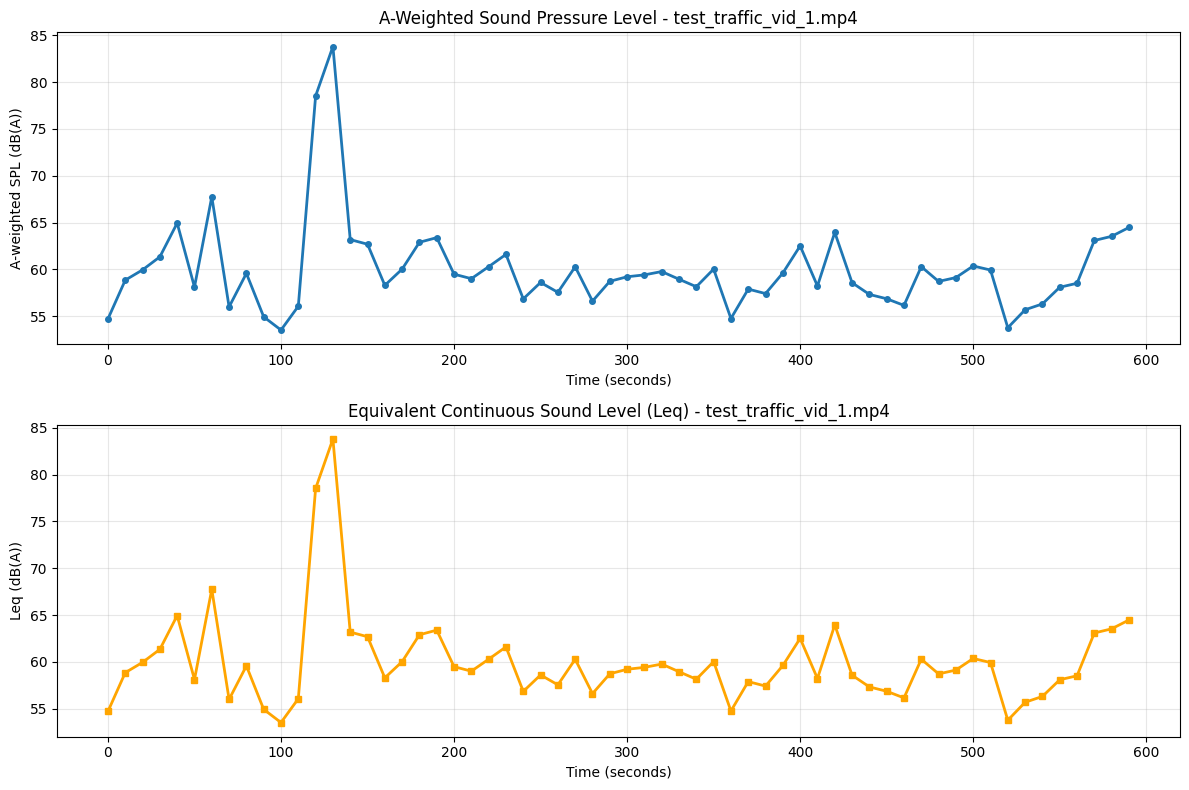

Plotted noise levels for 60 chunks


In [19]:
import matplotlib.pyplot as plt

if results:
    sample_filename = list(results.keys())[0]
    noise_summary = processor.get_noise_summary(sample_filename)
    
    if 'error' not in noise_summary:
        analysis_data = noise_summary.get('analysis', [])
        
        # Extract data for plotting
        chunk_numbers = list(range(len(analysis_data)))
        spl_values = [d.get('a_weighted_spl', 0) for d in analysis_data]
        leq_values = [d.get('leq_a', 0) for d in analysis_data]
        time_points = [i * CHUNK_DURATION for i in chunk_numbers]
        
        # Create plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # A-weighted SPL plot
        ax1.plot(time_points, spl_values, marker='o', linewidth=2, markersize=4)
        ax1.set_xlabel('Time (seconds)')
        ax1.set_ylabel('A-weighted SPL (dB(A))')
        ax1.set_title(f'A-Weighted Sound Pressure Level - {sample_filename}')
        ax1.grid(True, alpha=0.3)
        
        # Leq plot
        ax2.plot(time_points, leq_values, marker='s', color='orange', linewidth=2, markersize=4)
        ax2.set_xlabel('Time (seconds)')
        ax2.set_ylabel('Leq (dB(A))')
        ax2.set_title(f'Equivalent Continuous Sound Level (Leq) - {sample_filename}')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Plotted noise levels for {len(chunk_numbers)} chunks")
    else:
        print("No noise data available for plotting")
else:
    print("No files to plot. Process files first.")

## 9. Export Chunk Information to CSV

Export chunk metadata and noise levels to CSV for easy analysis.

In [20]:
import csv

if results:
    for filename in results.keys():
        base_name = Path(filename).stem
        noise_summary = processor.get_noise_summary(filename)
        
        if 'error' not in noise_summary:
            csv_path = processor.noise_analysis_dir / f"{base_name}_chunks.csv"
            
            # Write CSV with UTF-8 encoding to handle Unicode characters
            with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
                fieldnames = ['chunk_index', 'start_time', 'end_time', 'duration',
                            'audio_file', 'video_file', 
                            'a_weighted_spl', 'leq_a', 'rms', 'peak_db', 
                            'rms_db', 'crest_factor_db']
                
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writeheader()
                
                # Get chunk data
                chunk_meta_file = processor.chunk_metadata_dir / f"{base_name}_chunks.json"
                with open(chunk_meta_file, 'r') as f:
                    chunk_data = json.load(f)
                
                for chunk in chunk_data.get('chunks', []):
                    noise = chunk.get('noise_analysis', {})
                    
                    row = {
                        'chunk_index': chunk['chunk_index'],
                        'start_time': chunk['start_time'],
                        'end_time': chunk['end_time'],
                        'duration': chunk['duration'],
                        'audio_file': chunk['audio_chunk'],
                        'video_file': chunk['video_chunk'],
                        'a_weighted_spl': noise.get('a_weighted_spl', 0),
                        'leq_a': noise.get('leq_a', 0),
                        'rms': noise.get('rms', 0),
                        'peak_db': noise.get('peak_db', 0),
                        'rms_db': noise.get('rms_db', 0),
                        'crest_factor_db': noise.get('crest_factor_db', 0)
                    }
                    
                    writer.writerow(row)
            
            print(f"✓ Exported: {csv_path}")
    
    print(f"\nCSV files saved to: {processor.noise_analysis_dir}")
else:
    print("No files to export.")

✓ Exported: processed_media\noise_analysis\test_traffic_vid_1_chunks.csv

CSV files saved to: processed_media\noise_analysis


## 10. Find High/Low Noise Chunks

Identify chunks with highest and lowest noise levels.

In [21]:
if results:
    for filename in results.keys():
        noise_summary = processor.get_noise_summary(filename)
        
        if 'error' not in noise_summary:
            analysis_data = noise_summary.get('analysis', [])
            
            # Sort by A-weighted SPL
            sorted_by_spl = sorted(enumerate(analysis_data), 
                                  key=lambda x: x[1].get('a_weighted_spl', 0))
            
            print(f"\n{'='*70}")
            print(f"File: {filename}")
            print(f"{'='*70}")
            
            # Lowest noise chunks
            print(f"\nLOWEST NOISE CHUNKS (Top 3):")
            for idx, data in sorted_by_spl[:3]:
                print(f"  Chunk {idx} ({idx*CHUNK_DURATION:.1f}s - {(idx+1)*CHUNK_DURATION:.1f}s)")
                print(f"    SPL: {data.get('a_weighted_spl', 0):.2f} dB(A)")
                print(f"    File: {data.get('filename', 'N/A')}")
            
            # Highest noise chunks
            print(f"\nHIGHEST NOISE CHUNKS (Top 3):")
            for idx, data in sorted_by_spl[-3:][::-1]:
                print(f"  Chunk {idx} ({idx*CHUNK_DURATION:.1f}s - {(idx+1)*CHUNK_DURATION:.1f}s)")
                print(f"    SPL: {data.get('a_weighted_spl', 0):.2f} dB(A)")
                print(f"    File: {data.get('filename', 'N/A')}")
    
    print(f"\n{'='*70}")
else:
    print("No files to analyze.")


File: test_traffic_vid_1.mp4

LOWEST NOISE CHUNKS (Top 3):
  Chunk 10 (100.0s - 110.0s)
    SPL: 53.53 dB(A)
    File: test_traffic_vid_1_chunk_0010.wav
  Chunk 52 (520.0s - 530.0s)
    SPL: 53.78 dB(A)
    File: test_traffic_vid_1_chunk_0052.wav
  Chunk 0 (0.0s - 10.0s)
    SPL: 54.72 dB(A)
    File: test_traffic_vid_1_chunk_0000.wav

HIGHEST NOISE CHUNKS (Top 3):
  Chunk 13 (130.0s - 140.0s)
    SPL: 83.80 dB(A)
    File: test_traffic_vid_1_chunk_0013.wav
  Chunk 12 (120.0s - 130.0s)
    SPL: 78.52 dB(A)
    File: test_traffic_vid_1_chunk_0012.wav
  Chunk 6 (60.0s - 70.0s)
    SPL: 67.76 dB(A)
    File: test_traffic_vid_1_chunk_0006.wav

